![head.png](https://github.com/cafawo/FinancialDataAnalytics/blob/master/figures/head.jpg?raw=1)

# Financial Data Analytics in Python

**Prof. Dr. Fabian Woebbeking**</br>
Assistant Professor of Financial Economics

IWH - Leibniz Institute for Economic Research</br>
MLU - Martin Luther University Halle-Wittenberg

fabian.woebbeking@iwh-halle.de

# Homework: Value at Risk

You will need a Git/GitHub repository to submit your course deliverables. Consult [**slides.ipynb**](https://github.com/iwh-halle/FinancialDataAnalytics) for help with the tasks below! If you need further assistance, do not hesitate to open a Q&A at https://github.com/iwh-halle/FinancialDataAnalytics/discussions

In this assignment you will work with data that is stored in a file named **02_python_data.csv**, which contains daily stock prices for various companies listed on Deutsche Börse (Xetra). The columns are labeled with Reuters identifier code (RIC). The first RIC '.GDAXI' is the german DAX index, the remaining RICs represent its constituents.

### Task 1: 

Load the data and show in a single plot the cumulative log-returns of '.GDAXI' as well as an equally weighted portfolio of its constituents (all the other assets in 02_python_data.csv, excluding '.GDAXI').

In [1]:
import pandas as pd
df = pd.read_csv('02_python_data.csv')
df.head()

,Date,.GDAXI,SAPG.DE,SIEGn.DE,DTEGn.DE,AIRG.DE,ALVG.DE,MBGn.DE,VOWG_p.DE,BMWG.DE,...,CONG.DE,HEIG.DE,MTXGn.DE,CBKG.DE,RHMG.DE,BNRGn.DE,ZALG.DE,QIA.DE,PSHG_p.DE,1COV.DE
0,2022-04-29,14097.88,97.026932,117.78,17.570,105.50,216.20,67.10,148.94,78.51,...,66.02,55.26,193.65,6.282,214.8,73.94,37.83,44.04,79.54,41.29
1,2022-05-02,13939.07,95.982669,115.12,17.290,103.96,215.00,62.22,147.22,77.64,...,62.46,54.74,187.90,6.204,211.6,72.30,37.74,44.01,77.48,41.41
2,2022-05-03,14039.47,94.729554,114.56,17.376,106.44,217.00,62.88,150.20,79.98,...,64.32,55.22,197.10,6.412,222.4,72.18,38.07,44.06,79.58,39.40
3,2022-05-04,13970.82,92.979171,115.78,17.530,102.68,213.55,62.33,148.52,79.47,...,63.30,55.42,192.30,6.310,213.1,72.48,37.15,43.34,78.32,40.20
4,2022-05-05,13902.52,94.699718,116.58,17.592,108.96,199.76,61.00,147.18,78.03,...,60.54,54.18,189.95,6.188,211.0,71.34,33.21,44.05,77.78,38.75


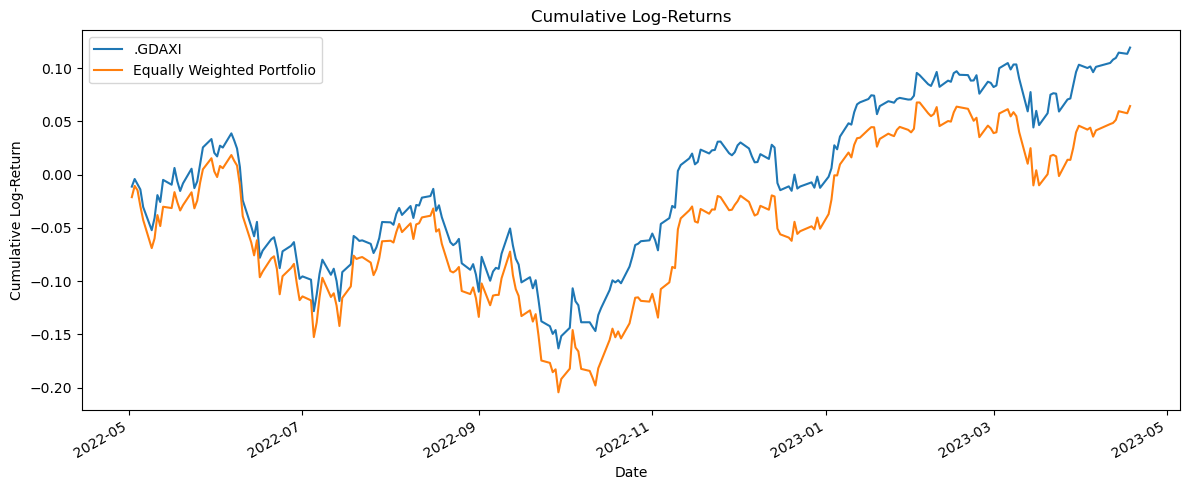

In [2]:
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('02_python_data.csv', index_col='Date', parse_dates=True)

# Log-Returns berechnen
log_returns = np.log(df / df.shift(1)).dropna()

# Kumulierte Log-Returns
gdaxi = log_returns['.GDAXI'].cumsum()

# Equally weighted portfolio (alle Spalten außer .GDAXI)
constituents = log_returns.drop(columns='.GDAXI')
portfolio = constituents.mean(axis=1).cumsum()

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
gdaxi.plot(ax=ax, label='.GDAXI')
portfolio.plot(ax=ax, label='Equally Weighted Portfolio')

ax.set_title('Cumulative Log-Returns')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Log-Return')
ax.legend()
plt.tight_layout()
plt.show()

### Task 2: 

We now want to compare the risk of **both** portfolios from the previous task ('.GDAXI and the equally weighted portfolio'). To do so, calculate the 95% 1-day [Value at Risk (VaR)](https://en.wikipedia.org/wiki/Value_at_risk), using:

* Historical simulation,
* the Parametric method,
* Monte Carlo simulation.

Add all values to a data frame and `display()`

In [3]:
from scipy import stats

n_simulations = 10_000
confidence = 0.95

assets = {
    '.GDAXI': log_returns['.GDAXI'],
    'EW Portfolio': constituents.mean(axis=1)
}

results = {}

for name, returns in assets.items():
    # Historical Simulation
    hist_var = -np.percentile(returns, (1 - confidence) * 100)

    # Parametric (Normal Distribution)
    mu, sigma = returns.mean(), returns.std()
    param_var = -(mu + stats.norm.ppf(1 - confidence) * sigma)

    # Monte Carlo Simulation
    simulated = np.random.normal(mu, sigma, n_simulations)
    mc_var = -np.percentile(simulated, (1 - confidence) * 100)

    results[name] = {
        'Historical Simulation': hist_var,
        'Parametric': param_var,
        'Monte Carlo': mc_var
    }

var_df = pd.DataFrame(results).T
display(var_df)

,Historical Simulation,Parametric,Monte Carlo
.GDAXI,0.019456,0.019416,0.019407
EW Portfolio,0.021996,0.020908,0.020816


### Task 3: 

In order to visualize the VaR results we focus only on '.GDAXI' (you can create `plt.subplots()` for the equally weighted portfolio if you like). In the plot:

1. Plot a histogram of the returns
2. Add a line plot of the normal distribution (parameterized to the returns)
3. Add indicators for the 3 VaRs (vertical lines or annotations)

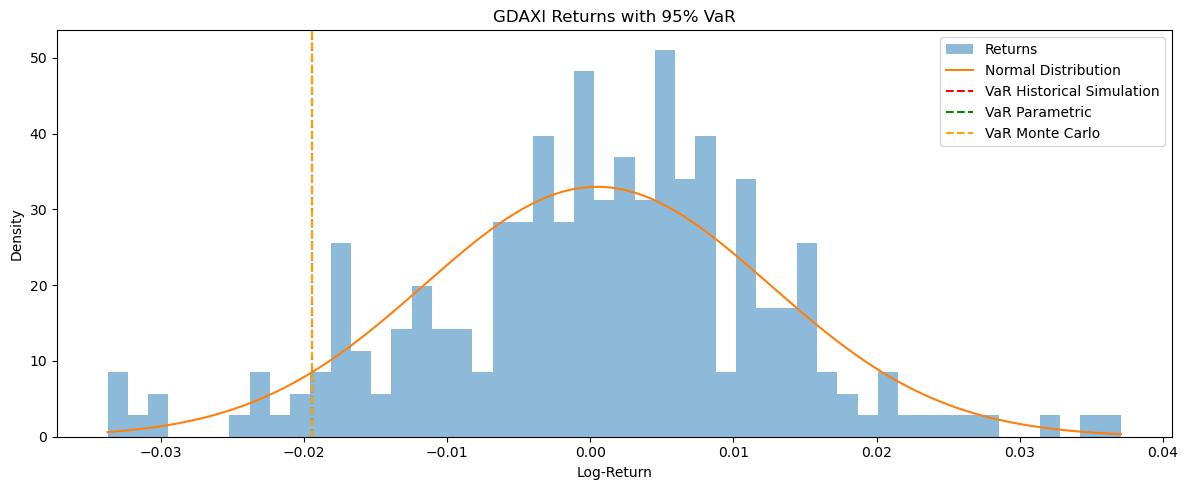

In [4]:
mu = log_returns['.GDAXI'].mean()
sigma = log_returns['.GDAXI'].std()

x = np.linspace(log_returns['.GDAXI'].min(), log_returns['.GDAXI'].max(), 1000)
normal_curve = stats.norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(12, 5))

# 1. Histogram
log_returns['.GDAXI'].plot.hist(ax=ax, bins=50, density=True, alpha=0.5, label='Returns')

# 2. Normal distribution curve
ax.plot(x, normal_curve, label='Normal Distribution')

# 3. VaR indicators
var_values = var_df.loc['.GDAXI']
colors = {'Historical Simulation': 'red', 'Parametric': 'green', 'Monte Carlo': 'orange'}

for method, color in colors.items():
    ax.axvline(-var_values[method], color=color, linestyle='--', linewidth=1.5, label=f'VaR {method}')

ax.set_title('GDAXI Returns with 95% VaR')
ax.set_xlabel('Log-Return')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()